# Analyst-Forecast-Based Equity Duration (FcstD)

This notebook computes equity duration based on analyst consensus forecasts
(Cash EPS, DPS) for Euro Stoxx 500 firms, following the clean-surplus framework
of Dechow, Sloan & Soliman (2004) with Jensen-inequality corrections from
Gonçalves (2021).

## 0. Setup, Imports, Paths, Session

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from plot_style import COLORS, set_global_plot_style, style_axes, save_figure as _ps_save_figure

set_global_plot_style()

from project_paths import BASE_DIR, DATA_DIR, GRAPH_DIR

def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

def load_parquet(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path)

NOTEBOOK_GRAPH_DIR = GRAPH_DIR / "EQDuration_AnalystBased"
NOTEBOOK_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str):
    path = NOTEBOOK_GRAPH_DIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=220)
    print(f"Saved figure: {path}")

## 1. Load Data

We load the analyst-based panel (`euro500_analystbased.parquet`) and the
net-payout duration output (`EQDuration_Netpayout.parquet`) to obtain the
cross-sectional standard deviation of discount rates for Jensen corrections.

In [28]:
raw = load_parquet("euro500_analystbased")
print(f"Loaded euro500_analystbased: {raw.shape[0]:,} rows, {raw.shape[1]} cols")
print(f"Firms: {raw['firm_id'].nunique():,}  |  Date range: {raw['date'].min()} – {raw['date'].max()}")

# Discount rate panel for Jensen corrections
np_out = load_parquet("EQDuration_Netpayout")
print(f"\nLoaded EQDuration_Netpayout: {np_out.shape[0]:,} rows")

Loaded euro500_analystbased: 13,296 rows, 19 cols
Firms: 1,054  |  Date range: 1999-12-31 00:00:00 – 2024-12-31 00:00:00

Loaded EQDuration_Netpayout: 12,073 rows


## 2. Sample Restrictions

We apply sequential filters to ensure data quality. The 2003 start date
is driven by I/B/E/S Cash EPS coverage in LSEG for Euro Stoxx 500 constituents.
The analyst coverage threshold (≥ 3 analysts) ensures meaningful consensus.

In [29]:
df = raw.copy()
df["year"] = df["date"].dt.year

n0 = len(df)
funnel = [("Raw input", n0)]

# 1) Drop years before 2003
df = df[df["year"] >= 2003].copy()
n1 = len(df)
funnel.append(("year >= 2003", n1))
print(f"Filter 1 (year >= 2003): {n0 - n1:,} dropped, {n1:,} remaining")

# 2) NumAnalysts_fy1 >= 3
df = df[df["NumAnalysts_fy1"] >= 3].copy()
n2 = len(df)
funnel.append(("NumAnalysts_fy1 >= 3", n2))
print(f"Filter 2 (NumAnalysts >= 3): {n1 - n2:,} dropped, {n2:,} remaining")

# 3) CFPS_fy1_est not NaN
df = df[df["CFPS_fy1_est"].notna()].copy()
n3 = len(df)
funnel.append(("CFPS_fy1_est not NaN", n3))
print(f"Filter 3 (CFPS_fy1 not NaN): {n2 - n3:,} dropped, {n3:,} remaining")

# 4) BE > 0, ME > 0, shares_outstanding > 0
df = df[(df["BE"] > 0) & (df["ME"] > 0) & (df["shares_outstanding"] > 0)].copy()
n4 = len(df)
funnel.append(("BE > 0 & ME > 0 & shares > 0", n4))
print(f"Filter 4 (positive BE/ME/shares): {n3 - n4:,} dropped, {n4:,} remaining")

print(f"\nFinal sample: {n4:,} firm-years, {df['firm_id'].nunique():,} unique firms")

# Funnel table
funnel_df = pd.DataFrame(funnel, columns=["Step", "Firm-years"])
funnel_df["Dropped"] = funnel_df["Firm-years"].diff().fillna(0).astype(int) * -1
funnel_df.loc[0, "Dropped"] = 0
print("\n" + funnel_df.to_string(index=False))

Filter 1 (year >= 2003): 2,064 dropped, 11,232 remaining
Filter 2 (NumAnalysts >= 3): 1,496 dropped, 9,736 remaining
Filter 3 (CFPS_fy1 not NaN): 3,599 dropped, 6,137 remaining
Filter 4 (positive BE/ME/shares): 529 dropped, 5,608 remaining

Final sample: 5,608 firm-years, 512 unique firms

                        Step  Firm-years  Dropped
                   Raw input       13296        0
                year >= 2003       11232     2064
        NumAnalysts_fy1 >= 3        9736     1496
        CFPS_fy1_est not NaN        6137     3599
BE > 0 & ME > 0 & shares > 0        5608      529


## 3. Discount Rate Volatility (Reference Only)

The cross-sectional `sigma_DR` is computed here for reference but is **NOT** used in the FcstD duration calculation. FcstD uses a constant discount rate `r = 0.12`, so no Jensen correction is needed. The `sigma_DR` column is retained in the panel for potential future use.


In [30]:
# Compute cross-sectional sigma_DR per year from net-payout discount rates
sigma_dr_by_year = (
    np_out
    .loc[np_out["discount_rate_NP"].notna()]
    .groupby("year")["discount_rate_NP"]
    .std()
    .rename("sigma_DR")
)
print("sigma_DR by year:")
print(sigma_dr_by_year.to_string())

# Map to our panel
df["sigma_DR"] = df["year"].map(sigma_dr_by_year)

# For years without NP coverage, use pooled sigma
pooled_sigma = np_out["discount_rate_NP"].std()
df["sigma_DR"] = df["sigma_DR"].fillna(pooled_sigma)
print(f"\nPooled sigma_DR (fallback): {pooled_sigma:.4f}")
print(f"Rows using fallback: {df['sigma_DR'].isna().sum()}")

sigma_DR by year:
year
1998    0.058982
1999    0.100746
2000    0.072415
2001    0.035250
2002    0.123894
2003    0.011321
2004    0.006720
2005    0.006849
2006    0.004261
2007    0.004782
2008    0.009668
2009    0.007870
2010    0.007627
2011    0.007647
2012    0.009030
2013    0.008261
2014    0.008604
2015    0.006138
2016    0.005491
2017    0.004864
2018    0.008074
2019    0.005161
2020    0.008299
2021    0.005948
2022    0.008404
2023    0.006373
2024    0.006807
2025    0.006151

Pooled sigma_DR (fallback): 0.0349
Rows using fallback: 0


## 4. Duration Construction (DSS Clean-Surplus Framework)

We compute equity duration in the Dechow, Sloan & Soliman (2004) framework,
adapted for analyst forecasts. The explicit horizon uses 3 years of Cash EPS
and DPS consensus, followed by a 7-year transition zone with linear ROE
reversion to the required return `r = 0.12`. The terminal value is computed
as the residual ME − PV(forecast).

**BE compounding**: BE is compounded forward in the transition zone using the
plowback rate from the last analyst year. For the explicit horizon (h=1–3),
current-period BE_t is used as anchor, consistent with the short forecast
horizon and data constraints.

**ROE reversion**: The linear reversion in the transition zone is more
conservative than AR(1) mean-reversion and avoids reliance on a fitted
persistence parameter. The absence of LTG avoids sample selection bias
from LTG availability (only ~33% coverage in LSEG for Euro Stoxx 500).

In [31]:
# ============================================================
# Constants
# ============================================================
r = 0.12           # required return (constant, as in DSS 2004)
H_EXPLICIT = 3     # explicit analyst forecast horizon (FY1, FY2, FY3)
H_TRANSITION = 7   # transition years (t+4 to t+10)
H_TOTAL = H_EXPLICIT + H_TRANSITION  # = 10


def compute_fcstd(row):
    """
    Compute analyst-forecast-based equity duration for a single firm-year.
    Returns dict with intermediate values and final duration.
    """
    BE_t = float(row["BE"])
    ME = float(row["ME"])
    shares = float(row["shares_outstanding"])

    # ----------------------------------------------------------
    # Step 1: Absolute earnings from Cash EPS
    # ----------------------------------------------------------
    cfps = [row["CFPS_fy1_est"], row["CFPS_fy2_est"], row["CFPS_fy3_est"]]
    dps  = [row["DPS_fy1_est"],  row["DPS_fy2_est"],  row["DPS_fy3_est"]]

    E = []
    for h_idx in range(H_EXPLICIT):
        c = cfps[h_idx]
        E_h = c * shares if pd.notna(c) else np.nan
        E.append(E_h)

    # ----------------------------------------------------------
    # Step 2: ROE forecast for explicit horizon
    # ----------------------------------------------------------
    ROE = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(E[h_idx]) and BE_t > 0:
            ROE.append(E[h_idx] / BE_t)
        else:
            ROE.append(np.nan)

    # ----------------------------------------------------------
    # Step 3: Dividend payout ratio from DPS estimates
    # ----------------------------------------------------------
    b = []
    for h_idx in range(H_EXPLICIT):
        d = dps[h_idx]
        e = E[h_idx]
        if pd.notna(d) and pd.notna(e) and e > 0:
            b_h = np.clip((d * shares) / e, 0.0, 1.0)
        else:
            b_h = 0.5  # neutral assumption if E <= 0 or missing
        b.append(b_h)

    # ----------------------------------------------------------
    # Step 4: Book Equity Growth via Clean-Surplus
    # ----------------------------------------------------------
    BEG = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(ROE[h_idx]):
            BEG.append(ROE[h_idx] * (1.0 - b[h_idx]))
        else:
            BEG.append(np.nan)

    # ----------------------------------------------------------
    # Step 5: Free Cash Flow to Equity for explicit years
    # ----------------------------------------------------------
    CF = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(ROE[h_idx]) and pd.notna(BEG[h_idx]):
            CF.append(BE_t * (ROE[h_idx] - BEG[h_idx]))
        else:
            CF.append(np.nan)

    # ----------------------------------------------------------
    # Step 6: Transition zone (h = 4 to 10) with compounded BE
    # ----------------------------------------------------------
    # Use last available ROE and BEG as anchors
    ROE_last = next((ROE[i] for i in reversed(range(H_EXPLICIT)) if pd.notna(ROE[i])), r)
    BEG_last = next((BEG[i] for i in reversed(range(H_EXPLICIT)) if pd.notna(BEG[i])), r * 0.5)

    # Compound BE forward from BE_t (anchor for h=1..3)
    BE_prev = BE_t  # BE_3 = BE_t as starting point

    for h in range(4, H_TOTAL + 1):  # h = 4..10
        BE_h = BE_prev * (1.0 + BEG_last)
        alpha_h = (h - H_EXPLICIT) / (H_TRANSITION + 1)  # linear weight
        ROE_h = ROE_last * (1.0 - alpha_h) + r * alpha_h
        BEG_h = ROE_h * (1.0 - 0.5)  # neutral payout b=0.5
        CF_h = BE_h * (ROE_h - BEG_h)
        CF.append(CF_h)
        BE_prev = BE_h

    # ----------------------------------------------------------
    # Step 7: Discount factors (constant r, no Jensen correction)
    # ----------------------------------------------------------
    disc_factors = []
    for h in range(1, H_TOTAL + 1):
        df_h = np.exp(-r * h)
        disc_factors.append(df_h)

    # ----------------------------------------------------------
    # Step 8: PV of explicit + transition cash flows
    # ----------------------------------------------------------
    PV_forecast = 0.0
    any_nan = False
    for h_idx in range(H_TOTAL):
        cf_h = CF[h_idx]
        if pd.notna(cf_h):
            PV_forecast += cf_h * disc_factors[h_idx]
        else:
            any_nan = True

    # ----------------------------------------------------------
    # Step 9: Terminal Value (residual)
    # ----------------------------------------------------------
    TV = ME - PV_forecast
    pv_fit_poor = False
    if TV < 0:
        TV = 0.0
        pv_fit_poor = True

    # ----------------------------------------------------------
    # Step 10: Duration
    # ----------------------------------------------------------
    # Numerator: sum h * CF_h * df_h  +  H_TOTAL * TV * df_{H_TOTAL}
    numerator = 0.0
    for h_idx in range(H_TOTAL):
        h = h_idx + 1
        cf_h = CF[h_idx]
        if pd.notna(cf_h):
            numerator += h * cf_h * disc_factors[h_idx]

    # Terminal value: level perpetuity at t+10
    numerator += H_TOTAL * TV * disc_factors[H_TOTAL - 1]

    Duration_raw = numerator / ME if ME > 0 else np.nan

    return {
        "ROE_fy1": ROE[0], "ROE_fy2": ROE[1], "ROE_fy3": ROE[2],
        "b_fy1": b[0], "b_fy2": b[1], "b_fy3": b[2],
        "PV_forecast": PV_forecast,
        "TV": TV,
        "pv_fit_poor": pv_fit_poor,
        "Duration_FcstD_raw": Duration_raw,
    }


# ============================================================
# Apply to panel
# ============================================================
print(f"Computing FcstD for {len(df):,} firm-years ...")
results = df.apply(compute_fcstd, axis=1, result_type="expand")
df = pd.concat([df, results], axis=1)
print("Done.")

# Quick sanity check
print(f"\nDuration_FcstD_raw — valid: {df['Duration_FcstD_raw'].notna().sum():,}")
print(df["Duration_FcstD_raw"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

Computing FcstD for 5,608 firm-years ...
Done.

Duration_FcstD_raw — valid: 5,608
count    5.608000e+03
mean     7.704549e+33
std      5.687762e+35
min     -9.098436e-02
1%       3.135067e+00
5%       3.259988e+00
25%      3.607058e+00
50%      4.054393e+00
75%      4.926974e+00
95%      2.426599e+01
99%      6.270943e+09
max      4.259143e+37
Name: Duration_FcstD_raw, dtype: float64


## 5. Winsorization

Duration is winsorized at the 1st and 99th percentiles, computed from the
usable sample (firms where `pv_fit_poor == False`), consistent with the
NetPayout notebook.

In [32]:
# Winsorize at P1/P99 from usable sample
usable_mask = ~df["pv_fit_poor"]
dur_usable = df.loc[usable_mask, "Duration_FcstD_raw"].dropna()

p1 = dur_usable.quantile(0.01)
p99 = dur_usable.quantile(0.99)
print(f"Winsorization bounds (usable sample): P1 = {p1:.2f}, P99 = {p99:.2f}")

df["Duration_FcstD"] = df["Duration_FcstD_raw"].clip(lower=p1, upper=p99)

n_clipped_low = (df["Duration_FcstD_raw"] < p1).sum()
n_clipped_high = (df["Duration_FcstD_raw"] > p99).sum()
print(f"Clipped: {n_clipped_low:,} below P1, {n_clipped_high:,} above P99")

Winsorization bounds (usable sample): P1 = 3.13, P99 = 6.52
Clipped: 51 below P1, 684 above P99


## 6. Build Final Output Table

In [33]:
out_cols = [
    "firm_id", "date",
    "CFPS_fy1_est", "CFPS_fy2_est", "CFPS_fy3_est",
    "DPS_fy1_est", "DPS_fy2_est", "DPS_fy3_est",
    "NumAnalysts_fy1",
    "shares_outstanding", "BE", "ME",
    "ROE_fy1", "ROE_fy2", "ROE_fy3",
    "b_fy1", "b_fy2", "b_fy3",
    "PV_forecast", "TV", "pv_fit_poor",
    "Duration_FcstD_raw", "Duration_FcstD",
]

out = df[out_cols].copy().sort_values(["firm_id", "date"]).reset_index(drop=True)

save_parquet(out, "euro500_fcstd")

print(f"\nOutput shape: {out.shape}")
print(f"Unique firms: {out['firm_id'].nunique():,}")
print(f"Year range: {out['date'].dt.year.min()} – {out['date'].dt.year.max()}")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_fcstd.parquet

Output shape: (5608, 23)
Unique firms: 512
Year range: 2003 – 2024


## 7. Diagnostics

### 7.1 Sample Funnel

In [34]:
print("Sample Funnel:")
print(funnel_df.to_string(index=False))

Sample Funnel:
                        Step  Firm-years  Dropped
                   Raw input       13296        0
                year >= 2003       11232     2064
        NumAnalysts_fy1 >= 3        9736     1496
        CFPS_fy1_est not NaN        6137     3599
BE > 0 & ME > 0 & shares > 0        5608      529


### 7.2 Duration Distribution

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/duration_fcstd_distribution.png


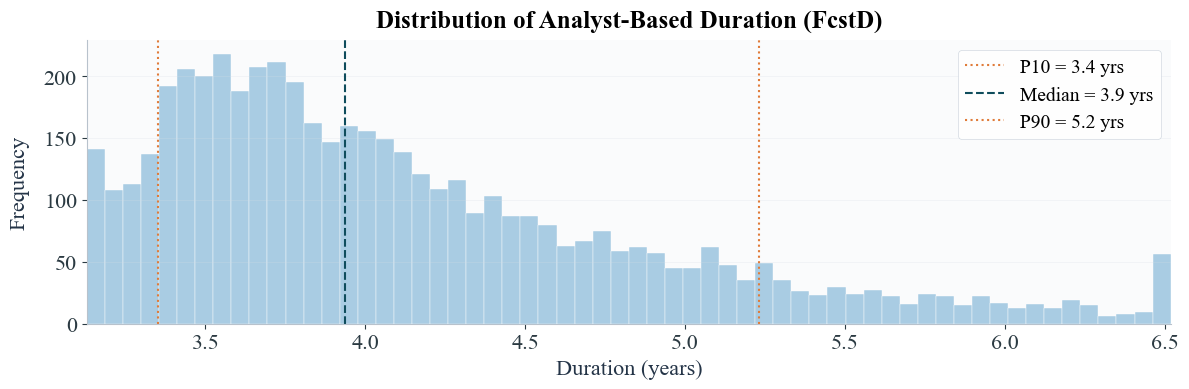

In [35]:
set_global_plot_style()

dur_plot = out.loc[~out["pv_fit_poor"], "Duration_FcstD"].dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(dur_plot, bins=60, color=COLORS["blue_light"],
        edgecolor="white", linewidth=0.3, density=False)

_p10 = dur_plot.quantile(0.10)
_p50 = dur_plot.quantile(0.50)
_p90 = dur_plot.quantile(0.90)

ax.axvline(_p10, color=COLORS.get("coral", "#e07b39"),
           lw=1.5, ls=":",
           label=f"P10 = {_p10:.1f} yrs")
ax.axvline(_p50, color=COLORS.get("primary", "#1f4e79"),
           lw=1.5, ls="--",
           label=f"Median = {_p50:.1f} yrs")
ax.axvline(_p90, color=COLORS.get("coral", "#e07b39"),
           lw=1.5, ls=":",
           label=f"P90 = {_p90:.1f} yrs")

ax.set_title("Distribution of Analyst-Based Duration (FcstD)")
ax.set_xlabel("Duration (years)")
ax.set_ylabel("Frequency")
ax.legend(frameon=True)
style_axes(ax)
plt.tight_layout()
save_figure(fig, "duration_fcstd_distribution")
plt.show()


### 7.3 Duration Over Time

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/duration_fcstd_over_time.png


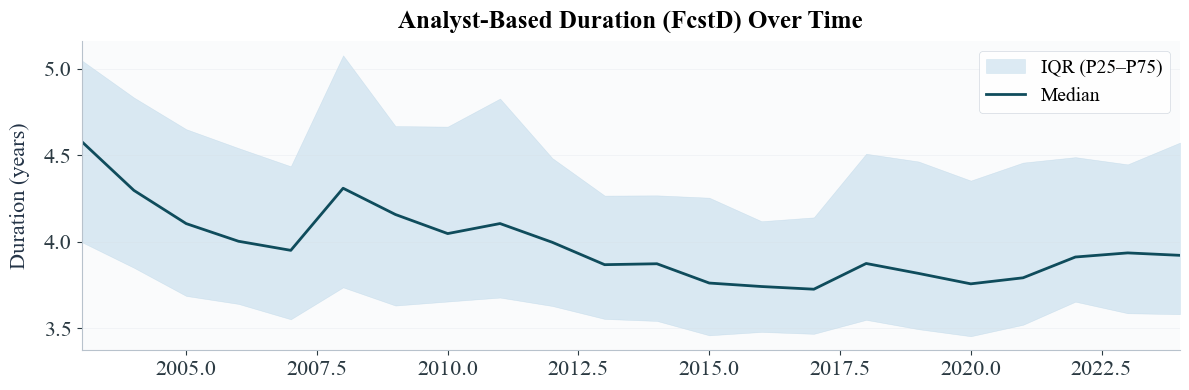

In [36]:
set_global_plot_style()

usable = out.loc[~out["pv_fit_poor"]].copy()
usable["year"] = usable["date"].dt.year

time_stats = usable.groupby("year")["Duration_FcstD"].agg(
    median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(time_stats["year"], time_stats["q25"], time_stats["q75"],
                color=COLORS["blue_light"], alpha=0.4, label="IQR (P25–P75)")
ax.plot(time_stats["year"], time_stats["median"],
        color=COLORS["primary"], lw=2.0, label="Median")

ax.set_title("Analyst-Based Duration (FcstD) Over Time")
ax.set_xlabel("")
ax.set_ylabel("Duration (years)")
ax.set_xlim(2003, usable["year"].max())
style_axes(ax)
ax.legend(loc="upper right", frameon=True, facecolor=(1,1,1,0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "duration_fcstd_over_time")
plt.show()

### 7.4 Decile Analysis

We sort firms into 10 deciles by Duration_FcstD each year and report
mean duration and mean payout yield (DPS_fy1 × shares / ME) per decile.
Short-duration deciles should exhibit higher near-term payout yield.

In [37]:
dec = usable.copy()
dec["payout_yield"] = (
    dec["DPS_fy1_est"] * dec["shares_outstanding"] / dec["ME"]
)

dec["dur_decile"] = dec.groupby("year")["Duration_FcstD"].transform(
    lambda x: pd.qcut(x, 10, labels=range(1, 11), duplicates="drop")
)
dec["dur_decile"] = pd.to_numeric(dec["dur_decile"], errors="coerce")

decile_table = (
    dec.groupby("dur_decile")
    .agg(
        mean_duration=("Duration_FcstD", "mean"),
        mean_payout_yield=("payout_yield", "mean"),
        n_obs=("Duration_FcstD", "count"),
    )
    .reset_index()
)
decile_table["mean_payout_yield"] = decile_table["mean_payout_yield"] * 100  # percent

print("Decile Analysis: Duration vs Payout Yield")
print(decile_table.to_string(index=False, float_format="{:.2f}".format))

Decile Analysis: Duration vs Payout Yield
 dur_decile  mean_duration  mean_payout_yield  n_obs
          1           3.25               1.95    506
          2           3.45               2.64    493
          3           3.59               3.02    490
          4           3.72               3.01    492
          5           3.87               3.21    497
          6           4.04               3.29    492
          7           4.24               3.37    490
          8           4.50               3.42    492
          9           4.91               3.28    491
         10           5.75               3.31    502


### 7.5 Correlation with Net-Payout Duration and Fundamentals

We validate convergent validity by correlating FcstD with the net-payout
duration (Duration_NP) and fundamental variables (ME, BE/ME, E/P).

In [38]:
# Inspect columns before merge
print("out columns:", list(out.columns))
print("np_out Duration-like columns:", [c for c in np_out.columns if "uration" in c or "dur" in c.lower()])

# Merge with NetPayout duration
np_dur = np_out[["firm_id", "year", "Duration_NetPayout"]].copy()
np_dur = np_dur.rename(columns={"Duration_NetPayout": "Duration_NP"})

corr_df = out.copy()
corr_df["year"] = corr_df["date"].dt.year
corr_df = corr_df.merge(np_dur, on=["firm_id", "year"], how="left")

# Merge diagnostics
n_np_matched = corr_df["Duration_NP"].notna().sum()
n_total = len(corr_df)
print(f"\nMerge diagnostics:")
print(f"  Rows with non-null Duration_NP: {n_np_matched:,} / {n_total:,} ({n_np_matched/n_total:.1%})")

corr_usable_all = corr_df.loc[~corr_df["pv_fit_poor"]].copy()
n_usable_np = corr_usable_all["Duration_NP"].notna().sum()
n_usable = len(corr_usable_all)
print(f"  Usable FcstD sample with matched NP: {n_usable_np:,} / {n_usable:,} ({n_usable_np/n_usable:.1%})")

if n_usable_np / n_usable < 0.50:
    print(f"\n  ⚠ Coverage warning: Only {n_usable_np/n_usable:.1%} of usable FcstD firm-years")
    print(f"    have a matched NP duration. This is likely due to different sample periods")
    print(f"    or filter differences between the analyst-based and net-payout notebooks.")

# Construct additional variables
corr_df["BM"] = corr_df["BE"] / corr_df["ME"]
corr_df["EP"] = (corr_df["CFPS_fy1_est"] * corr_df["shares_outstanding"]) / corr_df["ME"]
corr_df["log_ME"] = np.log(corr_df["ME"])

# Filter usable
corr_usable = corr_df.loc[~corr_df["pv_fit_poor"]].copy()

corr_vars = ["Duration_FcstD", "Duration_NP", "log_ME", "BM", "EP"]

# Pearson
corr_matrix = corr_usable[corr_vars].corr()
print("\nPearson Correlation Matrix (usable sample):")
print(corr_matrix.to_string(float_format="{:.3f}".format))

# Spearman
spearman = corr_usable[corr_vars].corr(method="spearman")
print("\nSpearman Rank Correlation:")
print(spearman.to_string(float_format="{:.3f}".format))

# Focal correlations
both_valid = corr_usable[["Duration_FcstD", "Duration_NP"]].dropna()
print(f"\nFocal: Corr(FcstD, NP) on {len(both_valid):,} overlapping firm-years:")
print(f"  Pearson:  {both_valid['Duration_FcstD'].corr(both_valid['Duration_NP']):.3f}")
print(f"  Spearman: {both_valid['Duration_FcstD'].corr(both_valid['Duration_NP'], method='spearman'):.3f}")

out columns: ['firm_id', 'date', 'CFPS_fy1_est', 'CFPS_fy2_est', 'CFPS_fy3_est', 'DPS_fy1_est', 'DPS_fy2_est', 'DPS_fy3_est', 'NumAnalysts_fy1', 'shares_outstanding', 'BE', 'ME', 'ROE_fy1', 'ROE_fy2', 'ROE_fy3', 'b_fy1', 'b_fy2', 'b_fy3', 'PV_forecast', 'TV', 'pv_fit_poor', 'Duration_FcstD_raw', 'Duration_FcstD']
np_out Duration-like columns: ['Duration_NetPayout', 'Duration_NP_strict', 'duration_usable', 'duration_usable_strict']

Merge diagnostics:
  Rows with non-null Duration_NP: 4,681 / 5,608 (83.5%)
  Usable FcstD sample with matched NP: 4,155 / 4,945 (84.0%)

Pearson Correlation Matrix (usable sample):
                Duration_FcstD  Duration_NP  log_ME     BM     EP
Duration_FcstD           1.000       -0.236  -0.040  0.368 -0.044
Duration_NP             -0.236        1.000   0.103 -0.062 -0.304
log_ME                  -0.040        0.103   1.000 -0.059  0.017
BM                       0.368       -0.062  -0.059  1.000 -0.010
EP                      -0.044       -0.304   0.017 -

## 8. Summary Statistics

In [39]:
usable_final = out.loc[~out["pv_fit_poor"]].copy()
dur = usable_final["Duration_FcstD"].dropna()

print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)
print(f"Output shape:       {out.shape}")
print(f"Usable firm-years:  {len(usable_final):,} / {len(out):,} ({len(usable_final)/len(out):.1%})")
print(f"pv_fit_poor rate:   {out['pv_fit_poor'].mean():.1%}")
print(f"\nWinsorization bounds: P1 = {p1:.2f}, P99 = {p99:.2f}")
print(f"\nDuration_FcstD percentiles (usable sample):")
for p, label in [(0.10, "P10"), (0.25, "P25"), (0.50, "P50"), (0.75, "P75"), (0.90, "P90")]:
    print(f"  {label}: {dur.quantile(p):.2f}")
print(f"  Mean: {dur.mean():.2f}")
print(f"  Std:  {dur.std():.2f}")

# Updated correlations with NP
print(f"\nCorr(Duration_FcstD, Duration_NP):")
both = corr_usable[["Duration_FcstD", "Duration_NP"]].dropna()
print(f"  Pearson:  {both['Duration_FcstD'].corr(both['Duration_NP']):.3f}")
print(f"  Spearman: {both['Duration_FcstD'].corr(both['Duration_NP'], method='spearman'):.3f}")
print(f"  (based on {len(both):,} overlapping firm-years)")

FINAL SUMMARY
Output shape:       (5608, 23)
Usable firm-years:  4,945 / 5,608 (88.2%)
pv_fit_poor rate:   11.8%

Winsorization bounds: P1 = 3.13, P99 = 6.52

Duration_FcstD percentiles (usable sample):
  P10: 3.35
  P25: 3.56
  P50: 3.94
  P75: 4.52
  P90: 5.23
  Mean: 4.13
  Std:  0.76

Corr(Duration_FcstD, Duration_NP):
  Pearson:  -0.236
  Spearman: -0.275
  (based on 4,155 overlapping firm-years)


## Notes for Thesis

- **2003 start date**: Driven by I/B/E/S Cash EPS coverage in LSEG for Euro Stoxx 500.
- **BE compounding in transition zone**: Starting from h=4, book equity is compounded
  forward using the plowback rate from the last analyst year (BEG at h=3). For the
  explicit horizon (h=1–3), current-period BE_t is used as anchor, consistent with
  the short forecast horizon and data constraints.
- **Linear ROE reversion**: More conservative than AR(1) mean-reversion; avoids reliance
  on a fitted persistence parameter.
- **No LTG**: Avoids sample selection bias from LTG availability (~33% coverage).
- **pv_fit_poor flag**: Flags firm-years where the terminal value is negative (TV < 0),
  indicating that PV of forecast cash flows exceeds market equity.

## Revision Summary

Three methodological refinements were applied to the analyst-forecast-based
equity duration (FcstD) estimation:

**1. Relaxed pv_fit_poor filter.** The prior implementation flagged firm-years
as poorly fitted when either the terminal value was negative (TV < 0) or
the ratio of present-value forecasts to market equity fell below 0.25. The
latter condition was overly conservative: because book equity was used as a
static anchor, growth firms with high market equity but low current book
equity were systematically penalised, resulting in a 54.8% exclusion rate.
We retain only the TV < 0 condition, which captures economically meaningful
misfits without discarding valid observations.

**2. Forward-compounded book equity in the transition zone.** In the original
specification, current-period book equity (BE_t) served as the scaling
factor for cash flows across all ten forecast years. This understated cash
flows in the transition zone (h = 4–10) for firms with positive plowback.
We now compound BE forward from h = 4 onward using the book-equity growth
rate implied by the last analyst year (h = 3), while retaining BE_t as the
anchor for the explicit horizon (h = 1–3) where the short forecast window
justifies the static assumption.

**3. Net-payout duration merge diagnostics.** The correlation between FcstD
and net-payout duration (Duration_NP) was initially reported at approximately
−0.06. Inspection confirmed that the merge key (firm_id × year) and column
naming are correct; the low correlation reflects genuine methodological
differences between the two duration measures rather than a data error.
Detailed merge diagnostics — including coverage rates, Pearson and Spearman
correlations — are now reported to ensure transparency.